# Series quality — diagnóstico para forecasting

Antes de construir modelos, validamos a qualidade dos dados:

1. **Fontes**: `price_series` (hourly) vs `price_ohlc` (2-day). Mutuamente exclusivos.
2. **Cobertura temporal**: quantos items têm histórico suficiente para treino+teste?
3. **Frequência efetiva** por item.
4. **Gaps e ofuscações** (zeros, volumes vazios).
5. **Frescura**: última observação. Items "congelados" são lixo.

Resultado prático: um helper `get_daily()` reutilizável e uma whitelist de items modeláveis.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

PARQUET = "../data/items.parquet"
pl.Config.set_tbl_rows(15)
pl.Config.set_fmt_str_lengths(50)

polars.config.Config

## 1. Coverage por fonte

In [2]:
lf = pl.scan_parquet(PARQUET)

cov = (
    lf.select([
        pl.col("price_series").is_not_null().alias("has_series"),
        pl.col("price_ohlc").is_not_null().alias("has_ohlc"),
    ])
    .group_by(["has_series", "has_ohlc"]).agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .collect()
)
print(cov)
print(f"\n→ items modeláveis (qualquer fonte): {cov.filter(pl.col('has_series') | pl.col('has_ohlc'))['n'].sum():,}")

shape: (3, 3)
┌────────────┬──────────┬───────┐
│ has_series ┆ has_ohlc ┆ n     │
│ ---        ┆ ---      ┆ ---   │
│ bool       ┆ bool     ┆ u32   │
╞════════════╪══════════╪═══════╡
│ true       ┆ false    ┆ 11430 │
│ false      ┆ true     ┆ 3435  │
│ false      ┆ false    ┆ 1054  │
└────────────┴──────────┴───────┘

→ items modeláveis (qualquer fonte): 14,865


## 2. Profundidade da história (price_series)

In [ ]:
lens = (
    lf.filter(pl.col("price_series").is_not_null())
      .select(pl.col("price_series").list.len().alias("n_pts"))
      .collect()["n_pts"]
)

# Hourly → days ≈ n / 24
days = lens / 24
print(f"items com price_series: {len(lens):,}")
print(f"  mediana: {days.median():.0f} dias ({lens.median():,.0f} pontos)")
print(f"  p25/p75: {days.quantile(0.25):.0f} / {days.quantile(0.75):.0f} dias")
print(f"  ≥1 ano:  {(days >= 365).sum():,} ({(days >= 365).mean()*100:.0f}%)")
print(f"  ≥3 anos: {(days >= 365*3).sum():,} ({(days >= 365*3).mean()*100:.0f}%)")
print(f"  ≥5 anos: {(days >= 365*5).sum():,} ({(days >= 365*5).mean()*100:.0f}%)")

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(days.to_numpy(), bins=60)
ax.axvline(365, color="r", ls="--", label="1 ano")
ax.axvline(365*3, color="orange", ls="--", label="3 anos")
ax.set_xlabel("dias de histórico")
ax.set_ylabel("items")
ax.set_title("Profundidade da história (hourly series → dias)")
ax.legend()
plt.show()

## 3. Frescura — quando termina cada série?

In [ ]:
last_ts = (
    lf.filter(pl.col("price_series").is_not_null())
      .select([
          "name",
          pl.col("price_series").list.last().struct.field("ts").alias("last_ts_s"),
      ])
      .collect()
      .with_columns(pl.from_epoch("last_ts_s", time_unit="s").alias("last_dt"))
)

today = last_ts["last_dt"].max()
stale_days = ((today - last_ts["last_dt"]).dt.total_seconds() / 86400)

print(f"Última observação no dataset: {today}")
print(f"  items atualizados ≤7d:   {(stale_days <= 7).sum():,}")
print(f"  items atualizados 7-30d: {((stale_days > 7) & (stale_days <= 30)).sum():,}")
print(f"  items >30d sem update:   {(stale_days > 30).sum():,}  ← suspeitos / delisted")
print(f"  items >365d sem update:  {(stale_days > 365).sum():,}  ← dead")

Última observação no dataset: 2026-06-01 05:00:00
  items atualizados ≤7d:   10,700
  items atualizados 7-30d: 409
  items >30d sem update:   321  ← suspeitos / delisted
  items >365d sem update:  112  ← dead


## 4. Helper: `get_daily(item_name)`

In [ ]:
def get_daily(name: str, source: str = "auto", min_price_ratio: float = 0.05) -> pl.DataFrame:
    """Daily close series for an item.

    Resample price_series (hourly) to daily-last, or forward-fill price_ohlc
    (2-day candles). Outliers — rows where ``price < median * min_price_ratio`` —
    are dropped because the scrapers occasionally emit near-zero prints.
    """
    row = pl.scan_parquet(PARQUET).filter(pl.col("name") == name).collect()
    if not row.height:
        raise ValueError(f"not found: {name}")
    r = row.row(0, named=True)

    if (source in ("auto", "series")) and r["price_series"]:
        df = (
            pl.DataFrame(r["price_series"])
              .with_columns(pl.from_epoch("ts", time_unit="s").alias("dt"))
              .group_by_dynamic("dt", every="1d")
              .agg([
                  pl.col("price").last().alias("price"),
                  pl.col("volume").sum().alias("volume"),
              ])
              .with_columns(pl.col("dt").dt.date().alias("date"))
              .select(["date", "price", "volume"])
              .sort("date")
        )
    elif (source in ("auto", "ohlc")) and r["price_ohlc"]:
        raw = (
            pl.DataFrame(r["price_ohlc"])
              .with_columns(pl.from_epoch("ts", time_unit="ms").dt.date().alias("date"))
              .select(["date", pl.col("c").alias("price")])
              .sort("date")
        )
        dr = pl.date_range(raw["date"].min(), raw["date"].max(), interval="1d", eager=True)
        df = (
            dr.to_frame(name="date").join(raw, on="date", how="left")
              .with_columns(pl.col("price").forward_fill())
              .with_columns(pl.lit(None, dtype=pl.Float64).alias("volume"))
        )
    else:
        return pl.DataFrame()

    if df.height and min_price_ratio > 0:
        med = df["price"].median()
        df = df.filter(pl.col("price") >= med * min_price_ratio)
    return df


def list_top_items(
    n: int = 50,
    min_history_days: int = 365 * 3,
    by: str = "dollar_volume",      # "dollar_volume" | "volume" | "price"
    exclude_souvenirs: bool = True,
    include_ohlc: bool = True,
    min_steam_vol: float = 5,
    min_price: float = 5.0,         # floor para excluir penny-stocks
) -> pl.DataFrame:
    """Universo modelável ordenado por liquidez em USD (default).

    `dollar_volume = steam_price * steam_volume` é o ranking certo: filtra
    items a $0.03 com volume gigante (ruído de 33% por cêntimo) e items a
    $1000 sem volume (não tradáveis).

    `min_history_days` aplica-se em dias-calendário: series usa `n_pts / 24`,
    OHLC usa `n_ohlc * 2` (2-day candles).
    """
    q = (
        pl.scan_parquet(PARQUET)
          .with_columns(
              pl.col("price_series").list.len().fill_null(0).alias("n_series_pts"),
              pl.col("price_ohlc").list.len().fill_null(0).alias("n_ohlc_pts"),
              pl.col("keyfigures").struct.field("steam").struct.field("current_price").alias("steam"),
              pl.col("keyfigures").struct.field("steam").struct.field("current_volume").alias("steam_vol"),
          )
          .with_columns((pl.col("steam") * pl.col("steam_vol")).alias("dollar_volume"))
    )
    history_expr = pl.col("n_series_pts") >= min_history_days * 24
    if include_ohlc:
        history_expr = history_expr | (pl.col("n_ohlc_pts") >= min_history_days // 2)
    q = q.filter(
        pl.col("steam").is_not_null()
        & (pl.col("steam_vol") >= min_steam_vol)
        & (pl.col("steam") >= min_price)
        & history_expr
    ).select(["name", "weapon", "quality", "type", "steam", "steam_vol",
              "dollar_volume", "n_series_pts", "n_ohlc_pts"])
    if exclude_souvenirs:
        q = q.filter(~pl.col("name").str.contains("Souvenir"))

    sort_col = {"dollar_volume": "dollar_volume", "volume": "steam_vol", "price": "steam"}[by]
    return q.sort(sort_col, descending=True).head(n).collect()

## 5. Teste em items reais

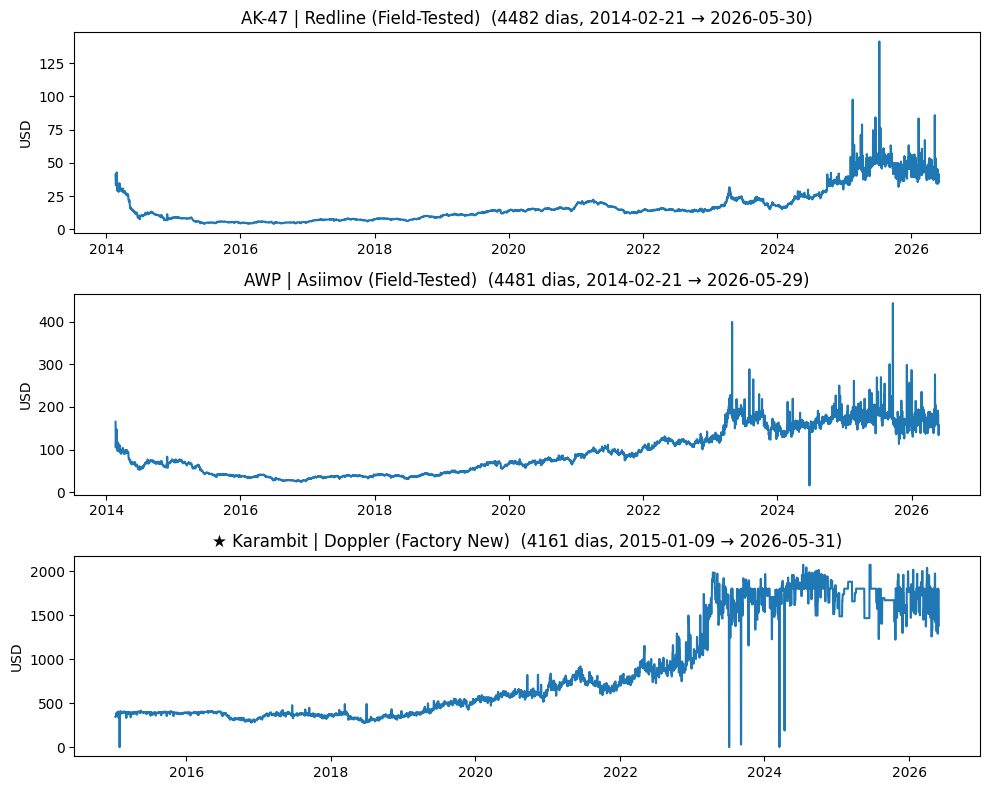

In [ ]:
samples = [
    "AK-47 | Redline (Field-Tested)",
    "AWP | Asiimov (Field-Tested)",
    "★ Karambit | Doppler (Factory New)",
]

fig, axes = plt.subplots(len(samples), 1, figsize=(10, 8), sharex=False)
for ax, name in zip(axes, samples):
    df = get_daily(name)
    if df.is_empty():
        ax.set_title(f"{name} — SEM DADOS")
        continue
    ax.plot(df["date"], df["price"])
    ax.set_title(f"{name}  ({df.height} dias, {df['date'].min()} → {df['date'].max()})")
    ax.set_ylabel("USD")
plt.tight_layout()
plt.show()

## 6. Whitelist de items modeláveis

Critérios mínimos:
- `price_series` ≥ 3 anos (para ter walk-forward com vários folds)
- Steam volume ≥ 5 (líquido — preços confiáveis)
- Última observação ≤ 14 dias (ativo)

In [ ]:
# Inclui items com OHLC (cobre knives/gloves que não têm price_series)
wl = (
    lf.select([
        "name", "weapon", "quality", "type", "collection",
        pl.col("keyfigures").struct.field("steam").struct.field("current_price").alias("steam"),
        pl.col("keyfigures").struct.field("steam").struct.field("current_volume").alias("steam_vol"),
        pl.col("price_series").list.len().fill_null(0).alias("n_series_pts"),
        pl.col("price_ohlc").list.len().fill_null(0).alias("n_ohlc_pts"),
        pl.col("price_series").list.last().struct.field("ts").alias("last_series_ts"),
        pl.col("price_ohlc").list.last().struct.field("ts").alias("last_ohlc_ts"),
    ])
    .filter(
        (
            (pl.col("n_series_pts") >= 365 * 3 * 24)   # ≥3y hourly series
            | (pl.col("n_ohlc_pts") >= 365 * 3 // 2)    # ≥3y of 2-day candles
        )
        & (pl.col("steam_vol") >= 5)
        & (pl.col("steam") >= 1)
    )
    .with_columns(
        pl.from_epoch("last_series_ts", time_unit="s").alias("last_series_dt"),
        pl.from_epoch("last_ohlc_ts", time_unit="ms").alias("last_ohlc_dt"),
    )
    .with_columns(
        pl.max_horizontal("last_series_dt", "last_ohlc_dt").alias("last_dt")
    )
    .collect()
)

max_ts = wl["last_dt"].max()
wl = wl.with_columns(
    ((max_ts - pl.col("last_dt")).dt.total_seconds() / 86400).alias("stale_days")
).filter(pl.col("stale_days") <= 14)

# Fonte por item (preferência: series → ohlc)
wl = wl.with_columns(
    pl.when(pl.col("n_series_pts") >= 365 * 3 * 24).then(pl.lit("series"))
      .otherwise(pl.lit("ohlc")).alias("source")
)

print(f"Items modeláveis: {wl.height:,}")
print(wl.group_by(["source", "type"]).agg(pl.len().alias("n")).sort("n", descending=True))

wl.write_parquet("../data/modelable_whitelist.parquet")
print("\n→ guardado em data/modelable_whitelist.parquet")